In [ ]:
import collections
import importlib
import math
from pathlib import Path
from typing import Callable, Dict, Optional, Sequence, Tuple, Union

import numpy as np
import torch.nn as nn
import torchvision
from diffusers.optimization import get_scheduler
from diffusers.schedulers.scheduling_ddpm import DDPMScheduler
from diffusers.training_utils import EMAModel

#from rich import print
from tqdm.auto import tqdm

In [2]:
import os
import sys

src_parent = os.path.abspath(os.path.join(os.path.dirname(os.getcwd())))
sys.path.append(src_parent)

import scripts
from scripts.image_dataset import PushTImageDataset, normalize_data, unnormalize_data
from scripts.models import ConditionalUnet1D, VisionEncoder
from scripts.pusht_image_env import PushTImageEnv
from scripts.training_Inference import UnetTrainer

/home/thankgod/2025/msc_project/msc_project_new/lib/python3.10/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [3]:
from IPython.display import Video
from skvideo.io import vwrite

from scripts.model_config import TrainingConfig

In [4]:
from transformers import AutoConfig, AutoImageProcessor, AutoModel

ModuleNotFoundError: No module named 'transformers'

# PushT dataset


In [5]:
# src_parent = os.path.abspath(os.path.join(os.path.dirname(os.getcwd())))
# print(src_parent) # ensure src directory is in sys.path
# sys.path.append(src_parent)

print(src_parent)

/home/thankgod/2025/msc_project/src


In [6]:
from omegaconf import OmegaConf
from torch.utils.data import DataLoader

In [ ]:
import gym
import hydra
import imagecodecs
import numpy
import omegaconf
import torch

print("Gym version:", gym.__version__)
print("NumPy version:", numpy.__version__)
print("hydra version:", hydra.__version__)
print("imagecodecs version:", imagecodecs.__version__)
print("Torch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("OmegaConf version:", omegaconf.__version__)

Gym version: 0.21.0
NumPy version: 2.2.6
hydra version: 1.2.0
imagecodecs version: 2023.9.18
Torch version: 2.8.0+cu128
Torchvision version: 0.23.0+cu128
OmegaConf version: 2.3.0


In [8]:
# import importlib
# import pkg_resources

# for dist in pkg_resources.working_set:
#     name = dist.project_name
#     try:
#         mod = importlib.import_module(name)
#     except Exception as e:
#         print(f"{name} import failed: {e}")


In [8]:


from diffusion_policy.dataset.base_dataset import BaseImageDataset
from diffusion_policy.policy.diffusion_unet_image_policy import DiffusionUnetImagePolicy


In [9]:
# Load the config file
cfg = OmegaConf.load('../pushT_config.yaml')

In [10]:
# python -c "from omegaconf import OmegaConf; cfg = OmegaConf.load('../pushT_config.yaml'); hydra.utils.instantiate(cfg.task.dataset)"

In [ ]:
import os

from omegaconf import OmegaConf

# Relative path
config_path = '../pushT_config.yaml'

# Convert to absolute path
abs_path = os.path.abspath(config_path)

# Load the config
cfg = OmegaConf.load(abs_path)

print("Config loaded from:", abs_path)

Config loaded from: /home/thankgod/2025/msc_project/src/pushT_config.yaml


In [12]:
#print(cfg)
dataset: BaseImageDataset
dataset = hydra.utils.instantiate(cfg.task.dataset)
assert isinstance(dataset, BaseImageDataset)

# train dataset
train_dataloader = DataLoader(dataset, **cfg.dataloader)
normalizer = dataset.get_normalizer()

# configure validation dataset
val_dataset = dataset.get_validation_dataset()
val_dataloader = DataLoader(val_dataset, **cfg.val_dataloader)


In [13]:
batch = next(iter(train_dataloader))
batch.keys()

dict_keys(['obs', 'action'])

In [14]:
batch['obs'].keys()

dict_keys(['image', 'agent_pos'])

In [15]:
batch['obs']['image'].shape

torch.Size([32, 16, 3, 96, 96])

In [16]:
# # visualize data in batch
# batch = next(iter(train_dataloader))
# print("batch['image'].shape:", batch['image'].shape)
# print("batch['agent_pos'].shape:", batch['agent_pos'].shape)
# print("batch['action'].shape", batch['action'].shape)

In [17]:
batch.keys()

dict_keys(['obs', 'action'])

In [18]:
model: DiffusionUnetImagePolicy = hydra.utils.instantiate(cfg.policy)

In [19]:
model

DiffusionUnetImagePolicy(
  (obs_encoder): MultiImageObsEncoder(
    (key_model_map): ModuleDict(
      (image): ResNet(
        (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        (bn1): GroupNorm(4, 64, eps=1e-05, affine=True)
        (relu): ReLU(inplace=True)
        (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
        (layer1): Sequential(
          (0): BasicBlock(
            (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (bn1): GroupNorm(4, 64, eps=1e-05, affine=True)
            (relu): ReLU(inplace=True)
            (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (bn2): GroupNorm(4, 64, eps=1e-05, affine=True)
          )
          (1): BasicBlock(
            (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (bn1): GroupNorm(4, 64, eps=1e-05, a

In [20]:
optimizer = hydra.utils.instantiate(
            cfg.optimizer, params=model.parameters())


In [21]:
from diffusion_policy.env_runner.pusht_image_runner import PushTImageRunner

In [22]:
env_runner = hydra.utils.instantiate(
    cfg.task.env_runner,
    output_dir=None)

In [ ]:
import gym_util

print(gym_util.__file__)


ModuleNotFoundError: No module named 'gym_util'

In [24]:
dataset_path = Path.cwd().parent / "data/pusht/pusht_cchi_v7_replay.zarr"

# parameters
pred_horizon = 16
obs_horizon = 2
action_horizon = 8
#|o|o|                             observations: 2
#| |a|a|a|a|a|a|a|a|               actions executed: 8
#|p|p|p|p|p|p|p|p|p|p|p|p|p|p|p|p| actions predicted: 16

# create dataset from file
dataset = PushTImageDataset(
    dataset_path=dataset_path,
    pred_horizon=pred_horizon,
    obs_horizon=obs_horizon,
    action_horizon=action_horizon
)

dataset

In [25]:
#stats = dataset.stats

# create dataloader
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=64,
    num_workers=4,
    shuffle=True,
    # accelerate cpu-gpu transfer
    pin_memory=True,
    # don't kill worker process afte each epoch
    persistent_workers=True
)

#dataloader.get_normalizer()

In [26]:
#dataset_path = Path.cwd().parent / "data/low_dim_pusht" / "replay_buffer.zarr"


# save training data statistics (min, max) for each dim


# visualize data in batch
batch = next(iter(dataloader))
print("batch['image'].shape:", batch['image'].shape)
print("batch['agent_pos'].shape:", batch['agent_pos'].shape)
print("batch['action'].shape", batch['action'].shape)

batch['image'].shape: torch.Size([64, 2, 3, 96, 96])
batch['agent_pos'].shape: torch.Size([64, 2, 2])
batch['action'].shape torch.Size([64, 16, 2])


In [27]:
batch['image'][0, 0]

tensor([[[255., 248., 248.,  ..., 248., 248., 255.],
         [248., 222., 233.,  ..., 233., 222., 248.],
         [247., 233., 255.,  ..., 255., 233., 247.],
         ...,
         [247., 233., 255.,  ..., 255., 233., 247.],
         [248., 222., 233.,  ..., 233., 222., 248.],
         [255., 248., 248.,  ..., 248., 248., 255.]],

        [[255., 248., 248.,  ..., 248., 248., 255.],
         [248., 222., 233.,  ..., 233., 222., 248.],
         [247., 233., 255.,  ..., 255., 233., 247.],
         ...,
         [247., 233., 255.,  ..., 255., 233., 247.],
         [248., 222., 233.,  ..., 233., 222., 248.],
         [255., 248., 248.,  ..., 248., 248., 255.]],

        [[255., 248., 248.,  ..., 248., 248., 255.],
         [248., 222., 233.,  ..., 233., 222., 248.],
         [247., 233., 255.,  ..., 255., 233., 247.],
         ...,
         [247., 233., 255.,  ..., 255., 233., 247.],
         [248., 222., 233.,  ..., 233., 222., 248.],
         [255., 248., 248.,  ..., 248., 248., 255.]]]

In [28]:
batch['image'].shape

torch.Size([64, 2, 3, 96, 96])

In [29]:
nimage = batch['image'][:,:2].to('cpu')
nimage.shape

torch.Size([64, 2, 3, 96, 96])

In [30]:
#bat

# 1.1 Torch ResNet no weights Embedding Model


In [31]:
# fetch torch resnet model no weights
torch_resnet_model = torchvision.models.get_model("resnet18", weights=None)

In [41]:
print(torch_resnet_model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (layer2): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (downsample): Sequential(
        (0): Conv2d(64, 128, kernel_size=(1, 1), stride=(2, 2), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (1): BasicBlock(
      (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (layer3): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (downsample): Sequential(
        (0): Conv2d(128, 256, kernel_size=(1, 1), stride=(2, 2), bias=False)
        (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (1): BasicBlock(
      (conv1): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (layer4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(256, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (downsample): Sequential(
        (0): Conv2d(256, 512, kernel_size=(1, 1), stride=(2, 2), bias=False)
        (1): 

In [42]:
def replace_last_classifier_with_identity(model: nn.Module) -> nn.Module:
    """Replace the last top-level child module with nn.Identity."""
    children_list = list(model.named_children())
    if not children_list:
        raise ValueError("Model has no child layers to replace.")
    last_name, _ = children_list[-1]
    setattr(model, last_name, nn.Identity())
    return model

torch_resnet_model = replace_last_classifier_with_identity(torch_resnet_model)

In [43]:
def replace_submodules(
    root_module: nn.Module,
    predicate: Callable[[nn.Module], bool],
    func: Callable[[nn.Module], nn.Module]
) -> nn.Module:
    """Replace all submodules that match the predicate."""
    if predicate(root_module):
        return func(root_module)

    matches = [k.split('.') for k, m
        in root_module.named_modules(remove_duplicate=True)
        if predicate(m)]

    for *parent, k in matches:
        parent_module = root_module
        if parent:
            parent_module = root_module.get_submodule('.'.join(parent))

        src_module = parent_module[int(k)] if isinstance(parent_module, nn.Sequential) else getattr(parent_module, k)
        tgt_module = func(src_module)

        if isinstance(parent_module, nn.Sequential):
            parent_module[int(k)] = tgt_module
        else:
            setattr(parent_module, k, tgt_module)

    assert not any(predicate(m) for _, m in root_module.named_modules(remove_duplicate=True))
    return root_module

def replace_bn_with_gn(model: nn.Module, features_per_group: int = 16) -> nn.Module:
    """Replace all BatchNorm2d layers with GroupNorm, adjusting groups if needed."""
    def bn_to_gn(x: nn.BatchNorm2d) -> nn.GroupNorm:
        num_channels = x.num_features
        # Pick a valid number of groups
        num_groups = max(1, num_channels // features_per_group)
        # Ensure divisibility
        if num_channels % num_groups != 0:
            num_groups = math.gcd(num_channels, features_per_group) or 1
        return nn.GroupNorm(num_groups=num_groups, num_channels=num_channels)

    return replace_submodules(
        root_module=model,
        predicate=lambda m: isinstance(m, nn.BatchNorm2d),
        func=bn_to_gn
    )

torch_resnet_model = replace_bn_with_gn(torch_resnet_model)

In [44]:
dummy_image = torch.zeros((1, 3, 96, 96))
img_features = torch_resnet_model(dummy_image)
img_features.shape

torch.Size([1, 512])

In [45]:
dummy_image = torch.zeros((1, 3, 96, 96))
img_features = torch_resnet_model(dummy_image)
vision_feature_dim = img_features.shape[-1]

print("Vision Feature Dimension:", vision_feature_dim)

Vision Feature Dimension: 512

In [46]:
nimage.shape

torch.Size([64, 2, 3, 96, 96])

In [47]:
nimage.shape[:2]

torch.Size([64, 2])

In [48]:
nimage.flatten(end_dim=1).shape

torch.Size([128, 3, 96, 96])

In [49]:
torch_resnet_model(nimage.flatten(end_dim=1)).shape

torch.Size([128, 512])

In [50]:
torch_resnet_model(nimage.flatten(end_dim=1)).reshape(*nimage.shape[:2], -1).shape

torch.Size([64, 2, 512])

# 1.2 HuggingFace ResNet no weights Embedding Model


In [51]:
config = AutoConfig.from_pretrained("microsoft/resnet-18")
processor = AutoImageProcessor.from_pretrained("microsoft/resnet-18")

hf_resnet_model = AutoModel.from_config(config)
print(hf_resnet_model)

ResNetModel(
  (embedder): ResNetEmbeddings(
    (embedder): ResNetConvLayer(
      (convolution): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (normalization): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (activation): ReLU()
    )
    (pooler): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (encoder): ResNetEncoder(
    (stages): ModuleList(
      (0): ResNetStage(
        (layers): Sequential(
          (0): ResNetBasicLayer(
            (shortcut): Identity()
            (layer): Sequential(
              (0): ResNetConvLayer(
                (convolution): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
                (normalization): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
                (activation): ReLU()
              )
              (1): ResNetConvLayer(
                (convolution): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
                (normalization): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
                (activation): Identity()
              )
            )
            (activation): ReLU()
          )
          (1): ResNetBasicLayer(
            (shortcut): Identity()
            (layer): Sequential(
              (0): ResNetConvLayer(
                (convolution): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
                (normalization): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
                (activation): ReLU()
              )
              (1): ResNetConvLayer(
                (convolution): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
                (normalization): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
                (activation): Identity()
              )
            )
            (activation): ReLU()
          )
        )
      )
      (1): ResNetStage(
        (layers): Sequential(
          (0): ResNetBasicLayer(
            (shortcut): ResNetShortCut(
              (convolution): Conv2d(64, 128, kernel_size=(1, 1), stride=(2, 2), bias=False)
              (normalization): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            )
            (layer): Sequential(
              (0): ResNetConvLayer(
                (convolution): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
                (normalization): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
                (activation): ReLU()
              )
              (1): ResNetConvLayer(
                (convolution): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
                (normalization): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
                (activation): Identity()
              )
            )
            (activation): ReLU()
          )
          (1): ResNetBasicLayer(
            (shortcut): Identity()
            (layer): Sequential(
              (0): ResNetConvLayer(
                (convolution): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
                (normalization): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
                (activation): ReLU()
              )
              (1): ResNetConvLayer(
                (convolution): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
                (normalization): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
                (activation): Identity()
              )
            )
            (activation): ReLU()
          )
        )
      )
      (2): ResNetSt

In [52]:
img_features = hf_resnet_model(dummy_image)
img_features.keys()

odict_keys(['last_hidden_state', 'pooler_output'])

In [53]:
print("Feature shape:", img_features.last_hidden_state.shape)
print("Pooled shape:", img_features.pooler_output.shape)

Feature shape:
torch.Size([1, 512, 3, 3])

Pooled shape:
torch.Size([1, 512, 1, 1])

In [54]:
batch['image'][0, 0]

tensor([[[255., 248., 248.,  ..., 248., 248., 255.],
         [248., 222., 233.,  ..., 233., 222., 248.],
         [247., 233., 255.,  ..., 255., 233., 247.],
         ...,
         [247., 233., 255.,  ..., 255., 233., 247.],
         [248., 222., 233.,  ..., 233., 222., 248.],
         [255., 248., 248.,  ..., 248., 248., 255.]],

        [[255., 248., 248.,  ..., 248., 248., 255.],
         [248., 222., 233.,  ..., 233., 222., 248.],
         [247., 233., 255.,  ..., 255., 233., 247.],
         ...,
         [247., 233., 255.,  ..., 255., 233., 247.],
         [248., 222., 233.,  ..., 233., 222., 248.],
         [255., 248., 248.,  ..., 248., 248., 255.]],

        [[255., 248., 248.,  ..., 248., 248., 255.],
         [248., 222., 233.,  ..., 233., 222., 248.],
         [247., 233., 255.,  ..., 255., 233., 247.],
         ...,
         [247., 233., 255.,  ..., 255., 233., 247.],
         [248., 222., 233.,  ..., 233., 222., 248.],
         [255., 248., 248.,  ..., 248., 248., 255.]]]

In [61]:
inputs = processor(images=batch['image'][0, 0], return_tensors="pt")

inputs

{'pixel_values': tensor([[[[2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489],
          [2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489],
          [2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489],
          ...,
          [2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489],
          [2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489],
          [2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489]],

         [[2.4286, 2.4286, 2.4286,  ..., 2.4286, 2.4286, 2.4286],
          [2.4286, 2.4286, 2.4286,  ..., 2.4286, 2.4286, 2.4286],
          [2.4286, 2.4286, 2.4286,  ..., 2.4286, 2.4286, 2.4286],
          ...,
          [2.4286, 2.4286, 2.4286,  ..., 2.4286, 2.4286, 2.4286],
          [2.4286, 2.4286, 2.4286,  ..., 2.4286, 2.4286, 2.4286],
          [2.4286, 2.4286, 2.4286,  ..., 2.4286, 2.4286, 2.4286]],

         [[2.6400, 2.6400, 2.6400,  ..., 2.6400, 2.6400, 2.6400],
          [2.6400, 2.6400, 2.6400,  ..., 2.6400, 2.6400, 2.6400],
          [2.6400, 2.6400

In [56]:


img_features = hf_resnet_model(**inputs)
print("Processed output keys:", img_features.keys())
print("Feature shape:", img_features.last_hidden_state.shape)
print("Pooled shape:", img_features.pooler_output.shape)

Processed output keys: odict_keys(['last_hidden_state', 'pooler_output'])

Feature shape:
torch.Size([1, 512, 7, 7])

Pooled shape:
torch.Size([1, 512, 1, 1])

In [17]:
sample_image =  batch['image'][0, 0]
sample_image = sample_image.unsqueeze(0)
sample_image.shape

torch.Size([1, 3, 96, 96])

In [10]:
class ResNetVisionEncoderPretrained(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.resnet = AutoModel.from_pretrained(
            "microsoft/resnet-18",
            #device_map='auto'
        )

    def forward(self, x):
        # x shape: [batch, 3, H, W]
        outputs = self.resnet(x)
        return outputs.pooler_output.flatten(start_dim=1)

hf_vision_encoder_pretrained = ResNetVisionEncoderPretrained() #.to('cuda') #works without processing
vision_feature_dim = hf_vision_encoder_pretrained(sample_image      #.to('cuda')
                             ).shape[-1]

In [11]:
vision_feature_dim

512

In [25]:
dino_convnext_model_checkpoint = "facebook/dinov3-convnext-tiny-pretrain-lvd1689m"
dino_vit_model_checkpoint = "facebook/dinov3-vits16plus-pretrain-lvd1689m"
resnet_model_checkpoint = "microsoft/resnet-18"

In [26]:
class ResNetVisionEncoderNoPretrained(torch.nn.Module):
    def __init__(self, config_name):
        super().__init__()
        config = AutoConfig.from_pretrained(config_name)
        self.processor = AutoImageProcessor.from_pretrained(config_name)
        self.resnet = AutoModel.from_config(
            config,
            #device_map='auto'
        )

    def forward(self, x):
        # x shape: [batch, 3, H, W]
        outputs = self.resnet(x)
        return outputs.pooler_output.flatten(start_dim=1)


hf_vision_encoder_no_pretrained = ResNetVisionEncoderNoPretrained(dino_convnext_model_checkpoint)
vision_feature_dim = hf_vision_encoder_no_pretrained(sample_image).shape[-1]
vision_feature_dim

768

In [14]:
#hf_vision_encoder_no_pretrained(nimage.flatten(end_dim=1)).shape

In [15]:
class ResNetVisionEncoderFrozen(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.resnet = AutoModel.from_pretrained("microsoft/resnet-18")

        # Freeze all parameters
        for param in self.resnet.parameters():
            param.requires_grad = False

    def forward(self, x):
        # x shape: [batch, 3, H, W]
        with torch.no_grad():  # Extra safety to ensure no gradients
            outputs = self.resnet(x)
        return outputs.pooler_output.flatten(start_dim=1)

hf_vision_encoder_frozen = ResNetVisionEncoderFrozen()
vision_feature_dim = hf_vision_encoder_frozen(sample_image).shape[-1]

# Torch ResNet Frozen weights Embedding Model


# Dinov3 Model


# Unet Model


In [20]:
vision_feature_dim

384

In [27]:
# Example Input: Define the observation and agent position tensors
image = torch.zeros((1, obs_horizon, 3, 96, 96))
agent_pos = torch.zeros((1, obs_horizon, 2))
lowdim_obs_dim = agent_pos.shape[-1] # agent_pos is 2 dimensional
# observation feature depends on the selected model output
obs_dim = vision_feature_dim + lowdim_obs_dim
action_dim = 2


noise_pred_net = ConditionalUnet1D(
    input_dim=action_dim,  # input_dim (action_dim)
    global_cond_dim=obs_dim * obs_horizon,  # obs_dim=(512 + 2) * obs_horizon=2 -> 1028
)

nets = nn.ModuleDict({
    'vision_encoder': hf_vision_encoder_no_pretrained,
    'noise_pred_net': noise_pred_net
})

print(sum(p.numel() for p in nets.parameters()))

number of parameters 8.728730e+07


115107426

In [127]:
from transformers import AutoImageProcessor

In [96]:
resnet_model_checkpoint = "microsoft/resnet-18"
resnet_image_processor  = AutoImageProcessor.from_pretrained(resnet_model_checkpoint)
resnet_image_processor

ConvNextImageProcessor {
  "crop_pct": 0.875,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "ConvNextImageProcessor",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "resample": 3,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "shortest_edge": 224
  }
}

In [97]:
dino_model_checkpoint = "facebook/dinov3-convnext-tiny-pretrain-lvd1689m"
dino_image_processor  = AutoImageProcessor.from_pretrained(dino_model_checkpoint)
dino_image_processor

DINOv3ViTImageProcessorFast {
  "crop_size": null,
  "data_format": "channels_first",
  "default_to_square": true,
  "device": null,
  "disable_grouping": null,
  "do_center_crop": null,
  "do_convert_rgb": null,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "DINOv3ViTImageProcessorFast",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "input_data_format": null,
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "return_tensors": null,
  "size": {
    "height": 224,
    "width": 224
  }
}

In [85]:
batch.keys()

dict_keys(['agent_pos', 'action', 'image'])

In [ ]:
import torchvision
from torchvision import transforms


def make_transform():
    normalize = transforms.Normalize(
        mean=resnet_image_processor.image_mean,  # [0.485, 0.456, 0.406]
        std=resnet_image_processor.image_std,    # [0.229, 0.224, 0.225]
    )
    return transforms.Compose([
        transforms.Lambda(lambda x: x.float() / 255.0),  # Scale to [0,1]
        normalize
    ])

transform = make_transform()
#sample_image = [image.convert("RGB") for image in batch["image"]]
transform(sample_image)

tensor([[[[2.2489, 2.1290, 2.1290,  ..., 2.1290, 2.1290, 2.2489],
          [2.1290, 1.6838, 1.8722,  ..., 1.8722, 1.6838, 2.1290],
          [2.1119, 1.8722, 2.2489,  ..., 2.2489, 1.8722, 2.1119],
          ...,
          [2.1119, 1.8722, 2.2489,  ..., 2.2489, 1.8722, 2.1119],
          [2.1290, 1.6838, 1.8722,  ..., 1.8722, 1.6838, 2.1290],
          [2.2489, 2.1290, 2.1290,  ..., 2.1290, 2.1290, 2.2489]],

         [[2.4286, 2.3060, 2.3060,  ..., 2.3060, 2.3060, 2.4286],
          [2.3060, 1.8508, 2.0434,  ..., 2.0434, 1.8508, 2.3060],
          [2.2885, 2.0434, 2.4286,  ..., 2.4286, 2.0434, 2.2885],
          ...,
          [2.2885, 2.0434, 2.4286,  ..., 2.4286, 2.0434, 2.2885],
          [2.3060, 1.8508, 2.0434,  ..., 2.0434, 1.8508, 2.3060],
          [2.4286, 2.3060, 2.3060,  ..., 2.3060, 2.3060, 2.4286]],

         [[2.6400, 2.5180, 2.5180,  ..., 2.5180, 2.5180, 2.6400],
          [2.5180, 2.0648, 2.2566,  ..., 2.2566, 2.0648, 2.5180],
          [2.5006, 2.2566, 2.6400,  ..., 2

In [99]:
batch["image"]

tensor([[[[[255., 248., 248.,  ..., 248., 248., 255.],
           [248., 222., 233.,  ..., 233., 222., 248.],
           [247., 233., 255.,  ..., 255., 233., 247.],
           ...,
           [247., 233., 255.,  ..., 255., 233., 247.],
           [248., 222., 233.,  ..., 233., 222., 248.],
           [255., 248., 248.,  ..., 248., 248., 255.]],

          [[255., 248., 248.,  ..., 248., 248., 255.],
           [248., 222., 233.,  ..., 233., 222., 248.],
           [247., 233., 255.,  ..., 255., 233., 247.],
           ...,
           [247., 233., 255.,  ..., 255., 233., 247.],
           [248., 222., 233.,  ..., 233., 222., 248.],
           [255., 248., 248.,  ..., 248., 248., 255.]],

          [[255., 248., 248.,  ..., 248., 248., 255.],
           [248., 222., 233.,  ..., 233., 222., 248.],
           [247., 233., 255.,  ..., 255., 233., 247.],
           ...,
           [247., 233., 255.,  ..., 255., 233., 247.],
           [248., 222., 233.,  ..., 233., 222., 248.],
           [2

In [131]:
# from torchvision.transforms import (
#     CenterCrop,
#     Compose,
#     Normalize,
#     RandomHorizontalFlip,
#     RandomResizedCrop,
#     Resize,
#     ToTensor,
# )

# normalize = Normalize(mean=image_processor.image_mean, std=image_processor.image_std)
# if "height" in image_processor.size:
#     size = (image_processor.size["height"], image_processor.size["width"])
#     crop_size = size
#     max_size = None
# elif "shortest_edge" in image_processor.size:
#     size = image_processor.size["shortest_edge"]
#     crop_size = (size, size)
#     max_size = image_processor.size.get("longest_edge")

# train_transforms = Compose(
#         [
#             RandomResizedCrop(crop_size),
#             RandomHorizontalFlip(),
#             ToTensor(),
#             normalize,
#         ]
#     )

# val_transforms = Compose(
#         [
#             Resize(size),
#             CenterCrop(crop_size),
#             ToTensor(),
#             normalize,
#         ]
#     )

# def preprocess_train(example_batch):
#     """Apply train_transforms across a batch."""
#     example_batch["pixel_values"] = [
#         train_transforms(image.convert("RGB")) for image in example_batch["image"]
#     ]
#     return example_batch

# def preprocess_val(example_batch):
#     """Apply val_transforms across a batch."""
#     example_batch["pixel_values"] = [val_transforms(image.convert("RGB")) for image in example_batch["image"]]
#     return example_batch

In [23]:
trainer = UnetTrainer(nets, dataloader)

model_path = os.path.dirname(os.getcwd()) + '/saved_models'
ema_nets = trainer.train_diffusion_policy(10, False, model_path)

cuda


Epoch: 100%|██████████| 10/10 [21:04<00:00, 126.49s/it, loss=0.0465]


epoch/avg_loss,█▆▄▃▃▂▂▁▁▁
epoch/avg_timestep,▁▃▂▁█▂▂▆▃▃
epoch/final_lr,▆█▇▇▅▄▃▂▁▁
epoch/max_loss,█▅▃▄▂▂▁▁▁▁
epoch/min_loss,█▇▇▆▄▅▄▃▃▁
epoch/number,▁▂▃▃▄▅▆▆▇█
epoch/std_loss,██▄▅▂▂▂▂▂▁
train/batch_loss,▆█▇▅▇▇▆▄▄▅▄█▄▆▆▄▄▃▅▆▆▂█▃▂▃▅▃▂▄▄▂▄▂▄▄▁▂▅▅
train/epoch,▁▁▁▂▂▃▃▃▃▃▃▃▃▃▃▄▄▄▄▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇█████
train/global_step,▁▁▁▁▁▂▂▂▂▂▂▂▂▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▅▅▆▆▇▇▇▇████
train/grad_norm,█▇▅▃▆▅▅▃▃▃▄▃▂▁▃▂▃▃▁▁▂▃▃▁▁▁▂▂▁▂▁▂▁▂▁▁▂▁▂▁


Training completed and logged to wandb!


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
test_image = batch['image'][0, 0]  # [3, 96, 96] - first batch item, first observation
test_image = test_image.unsqueeze(0)  # [1, 3, 96, 96] - add batch dimension

In [ ]:
test_image

tensor([[[[255., 248., 248.,  ..., 248., 248., 255.],
          [248., 222., 233.,  ..., 233., 222., 248.],
          [247., 233., 255.,  ..., 255., 233., 247.],
          ...,
          [247., 233., 255.,  ..., 255., 233., 247.],
          [248., 222., 233.,  ..., 233., 222., 248.],
          [255., 248., 248.,  ..., 248., 248., 255.]],

         [[255., 248., 248.,  ..., 248., 248., 255.],
          [248., 222., 233.,  ..., 233., 222., 248.],
          [247., 233., 255.,  ..., 255., 233., 247.],
          ...,
          [247., 233., 255.,  ..., 255., 233., 247.],
          [248., 222., 233.,  ..., 233., 222., 248.],
          [255., 248., 248.,  ..., 248., 248., 255.]],

         [[255., 248., 248.,  ..., 248., 248., 255.],
          [248., 222., 233.,  ..., 233., 222., 248.],
          [247., 233., 255.,  ..., 255., 233., 247.],
          ...,
          [247., 233., 255.,  ..., 255., 233., 247.],
          [248., 222., 233.,  ..., 233., 222., 248.],
          [255., 248., 248.,  ...

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [65.0..255.0].


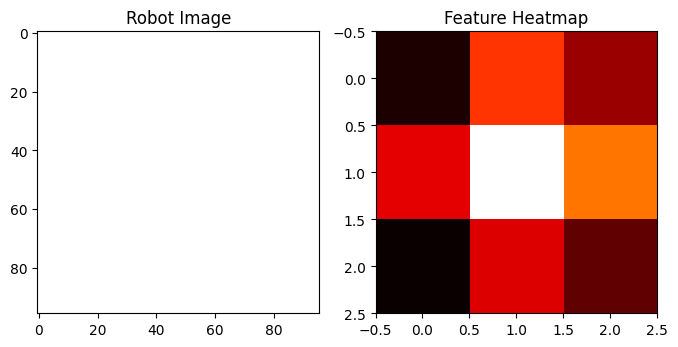

In [ ]:
def simple_feature_viz(nets, input_image):
    # Move input to same device as model
    device = next(nets['vision_encoder'].parameters()).device
    input_image = input_image.to(device)

    with torch.no_grad():
        # Get the feature maps before global pooling
        outputs = nets['vision_encoder'].resnet(pixel_values=input_image)
        feature_maps = outputs.last_hidden_state  # [1, 512, H, W]

    # Average across channels and normalize
    heatmap = torch.mean(feature_maps, dim=1).squeeze().cpu().numpy()
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())

    return heatmap

# Usage - make sure test_image is on correct device
test_image = batch['image'][0, 0].unsqueeze(0)  # [1, 3, 96, 96]
heatmap = simple_feature_viz(nets, test_image)  # Will auto-move to GPU

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(test_image.squeeze().permute(1, 2, 0).cpu().numpy())
plt.title('Robot Image')

plt.subplot(1, 2, 2)
plt.imshow(heatmap, cmap='hot')
plt.title('Feature Heatmap')
plt.show()